# IoT Intrusion Detection — Gradient Descent Binary Classification (From Scratch)

### Objective
Implement binary logistic regression **from scratch** with NumPy (sigmoid,
binary cross-entropy, gradient computation, parameter updates), comparing
Batch Gradient Descent against Mini-Batch Gradient Descent. This notebook is
educational — it demonstrates the optimization mechanics that scikit-learn's
`LogisticRegression` (used in notebook 06) hides behind a `.fit()` call. It
is not expected to beat scikit-learn's optimized solver.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score)

_candidates = [Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts",
               Path.cwd().parent, Path.cwd().parent.parent / "scripts"]
_scripts_dir = next((c for c in _candidates if (c / "common.py").exists()), None)
if _scripts_dir is None:
    raise FileNotFoundError(f"Could not locate scripts/common.py from cwd={Path.cwd()}")
sys.path.insert(0, str(_scripts_dir))
from common import PROCESSED_DIR, FEATSEL_DIR, FIGURES_DIR, METRICS_DIR, RANDOM_STATE

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
rng = np.random.RandomState(RANDOM_STATE)

## 1. Load Data (Scaled, Top-15 Features, Manageable Subset)

Gradient descent needs scaled inputs to converge well, so the `_processed`
(scaled) matrices from notebook 03 are used. A reproducible 50,000-row
training subsample keeps this from-scratch implementation fast without
changing which rows are used for evaluation.

In [2]:
top15_features = (FEATSEL_DIR / "top_15_features.txt").read_text().splitlines()
print("Using features:", top15_features)

X_train_full = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")[top15_features]
y_train_full = pd.read_csv(PROCESSED_DIR / "y_train.csv")["Label"]
X_val = pd.read_csv(PROCESSED_DIR / "X_validation_processed.csv")[top15_features]
y_val = pd.read_csv(PROCESSED_DIR / "y_validation.csv")["Label"]

SUBSAMPLE_N = min(50000, len(X_train_full))
sub_idx = X_train_full.sample(n=SUBSAMPLE_N, random_state=RANDOM_STATE).index
X_train = X_train_full.loc[sub_idx].to_numpy()
y_train = y_train_full.loc[sub_idx].to_numpy()
X_val_arr = X_val.to_numpy()
y_val_arr = y_val.to_numpy()

print(f"Training subsample: {X_train.shape} | Validation: {X_val_arr.shape}")

Using features: ['Dst_Port', 'Src_Port', 'ACK_Flag_Cnt', 'Flow_Duration', 'Bwd_IAT_Std', 'Init_Bwd_Win_Byts', 'Flow_Pkts/s', 'Flow_IAT_Max', 'Idle_Mean', 'Flow_IAT_Mean', 'Idle_Max', 'Fwd_Pkt_Len_Max', 'Bwd_Pkts/s', 'Fwd_Pkt_Len_Mean', 'Bwd_Header_Len']


Training subsample: (50000, 15) | Validation: (73872, 15)


## 2. Core Functions: Sigmoid, Loss, Gradients

In [3]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def binary_cross_entropy(y_true, y_pred_proba, sample_weight=None, eps=1e-12):
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)
    losses = -(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
    if sample_weight is not None:
        return float(np.average(losses, weights=sample_weight))
    return float(np.mean(losses))


def initialize_parameters(n_features):
    return np.zeros(n_features), 0.0


def compute_gradients(X, y_true, weights, bias, sample_weight=None):
    n = X.shape[0]
    y_pred = sigmoid(X @ weights + bias)
    error = y_pred - y_true
    if sample_weight is not None:
        error = error * sample_weight
        norm = sample_weight.sum()
    else:
        norm = n
    dw = (X.T @ error) / norm
    db = error.sum() / norm
    return dw, db

## 3. Batch and Mini-Batch Gradient Descent

Class-balanced sample weights (computed from **training labels only**) are
used throughout, since Anomaly is the majority class here.

In [4]:
def batch_gradient_descent(X, y, learning_rate=0.5, epochs=300, sample_weight=None):
    weights, bias = initialize_parameters(X.shape[1])
    losses = []
    for _ in range(epochs):
        dw, db = compute_gradients(X, y, weights, bias, sample_weight)
        weights -= learning_rate * dw
        bias -= learning_rate * db
        losses.append(binary_cross_entropy(y, sigmoid(X @ weights + bias), sample_weight))
    return weights, bias, losses


def mini_batch_gradient_descent(X, y, learning_rate=0.5, epochs=300, batch_size=512,
                                 sample_weight=None, random_state=RANDOM_STATE):
    weights, bias = initialize_parameters(X.shape[1])
    losses = []
    rng_local = np.random.RandomState(random_state)
    n = X.shape[0]
    for _ in range(epochs):
        perm = rng_local.permutation(n)
        X_shuf, y_shuf = X[perm], y[perm]
        sw_shuf = sample_weight[perm] if sample_weight is not None else None
        for start in range(0, n, batch_size):
            end = start + batch_size
            sw_batch = sw_shuf[start:end] if sw_shuf is not None else None
            dw, db = compute_gradients(X_shuf[start:end], y_shuf[start:end], weights, bias, sw_batch)
            weights -= learning_rate * dw
            bias -= learning_rate * db
        losses.append(binary_cross_entropy(y, sigmoid(X @ weights + bias), sample_weight))
    return weights, bias, losses


def predict_probability(X, weights, bias):
    return sigmoid(X @ weights + bias)


def predict_class(X, weights, bias, threshold=0.5):
    return (predict_probability(X, weights, bias) >= threshold).astype(int)


def evaluate_binary_classifier(y_true, y_pred, y_proba):
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_Precision": prec, "Macro_Recall": rec, "Macro_F1": f1,
        "ROC_AUC": roc_auc_score(y_true, y_proba),
    }

## 4. Train Both Variants

In [5]:
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight(class_weight="balanced", y=y_train)

EPOCHS = 300
t0 = time.perf_counter()
w_batch, b_batch, losses_batch = batch_gradient_descent(X_train, y_train, learning_rate=0.5,
                                                          epochs=EPOCHS, sample_weight=sw)
time_batch = time.perf_counter() - t0

t0 = time.perf_counter()
w_mini, b_mini, losses_mini = mini_batch_gradient_descent(X_train, y_train, learning_rate=0.5,
                                                            epochs=EPOCHS, batch_size=512, sample_weight=sw)
time_mini = time.perf_counter() - t0

print(f"Batch GD:      {EPOCHS} epochs in {time_batch:.2f}s, final loss={losses_batch[-1]:.4f}")
print(f"Mini-Batch GD: {EPOCHS} epochs in {time_mini:.2f}s, final loss={losses_mini[-1]:.4f}")

Batch GD:      300 epochs in 0.55s, final loss=0.3111
Mini-Batch GD: 300 epochs in 2.57s, final loss=0.2388


## 5. Loss Curves

Saved: figures/gradient_descent_loss_curves.png


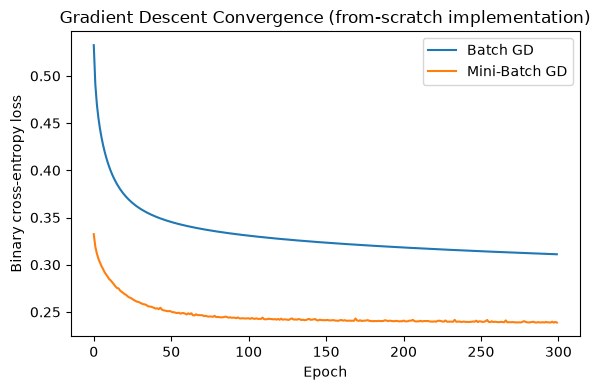

In [6]:
def plot_loss_curves(losses_batch, losses_mini):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(losses_batch, label="Batch GD")
    ax.plot(losses_mini, label="Mini-Batch GD")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Binary cross-entropy loss")
    ax.set_title("Gradient Descent Convergence (from-scratch implementation)")
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "gradient_descent_loss_curves.png", bbox_inches="tight")
    print("Saved: figures/gradient_descent_loss_curves.png")
    plt.show()


plot_loss_curves(losses_batch, losses_mini)

## 6. Validation Evaluation

In [7]:
results = []
for name, (w, b, t_sec) in {
    "Batch GD": (w_batch, b_batch, time_batch),
    "Mini-Batch GD": (w_mini, b_mini, time_mini),
}.items():
    proba = predict_probability(X_val_arr, w, b)
    pred = predict_class(X_val_arr, w, b)
    metrics = evaluate_binary_classifier(y_val_arr, pred, proba)
    metrics["Method"] = name
    metrics["Runtime_sec"] = t_sec
    metrics["Final_Loss"] = losses_batch[-1] if name == "Batch GD" else losses_mini[-1]
    results.append(metrics)

gd_results = pd.DataFrame(results)[["Method", "Accuracy", "Macro_Precision", "Macro_Recall",
                                     "Macro_F1", "ROC_AUC", "Runtime_sec", "Final_Loss"]]
print(gd_results.to_string(index=False))
gd_results.to_csv(METRICS_DIR / "gradient_descent_metrics.csv", index=False)
print("Saved: metrics/gradient_descent_metrics.csv")

       Method  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  ROC_AUC  Runtime_sec  Final_Loss
     Batch GD  0.845544         0.662537      0.862018  0.698714 0.940237     0.553791    0.311111
Mini-Batch GD  0.903224         0.725967      0.908866  0.778706 0.967526     2.566516    0.238753
Saved: metrics/gradient_descent_metrics.csv


### Observation
Mini-batch updates far more frequently per epoch than batch GD (one update
per batch vs. one per epoch), so it typically converges to a comparable loss
in a similar wall-clock time despite doing more arithmetic per epoch overall.
Neither variant is expected to match scikit-learn's `LogisticRegression`
(notebook 06), which uses a more sophisticated optimizer (L-BFGS) — this
comparison is purely for understanding the underlying mechanics.

## Notebook Summary

In [8]:
from IPython.display import display, Markdown

best_method = gd_results.loc[gd_results["Macro_F1"].idxmax(), "Method"]
summary_md = f"""
- Implemented logistic regression from scratch: `sigmoid`, `binary_cross_entropy`,
  gradient computation, and parameter updates — no scikit-learn model used here.
- Trained on a reproducible {SUBSAMPLE_N:,}-row subsample of the top-15 features
  for {EPOCHS} epochs, comparing **Batch GD** vs. **Mini-Batch GD**.
- Validation Macro-F1 was highest for **{best_method}**
  ({gd_results.set_index('Method').loc[best_method, 'Macro_F1']:.4f}).
- Saved loss-curve figure and `metrics/gradient_descent_metrics.csv`.

**Next notebook (`06_Logistic_Regression.ipynb`)** uses scikit-learn's
production-grade `LogisticRegression` with proper feature-count and
hyperparameter experiments, as the project's actual linear-model candidate.
"""
display(Markdown(summary_md))


- Implemented logistic regression from scratch: `sigmoid`, `binary_cross_entropy`,
  gradient computation, and parameter updates — no scikit-learn model used here.
- Trained on a reproducible 50,000-row subsample of the top-15 features
  for 300 epochs, comparing **Batch GD** vs. **Mini-Batch GD**.
- Validation Macro-F1 was highest for **Mini-Batch GD**
  (0.7787).
- Saved loss-curve figure and `metrics/gradient_descent_metrics.csv`.

**Next notebook (`06_Logistic_Regression.ipynb`)** uses scikit-learn's
production-grade `LogisticRegression` with proper feature-count and
hyperparameter experiments, as the project's actual linear-model candidate.
